# Conditionals and Iteration

--- 

## Overview

* [Comparison and Booleans](#Comparison-and-Booleans)
* [Applying a Function to a Row](#Applying-a-Function-to-a-Row)
* [Control Statements](#Control-Statements)
* [Random Selection](#Random-Selection)
* [Appending Arrays](#Appending-Arrays)
* [Iteration](#Iteration)
* [Optional: `bool` and `where`](#Optional:-bool-and-where)

--- 

## Set Up the Notebook

In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import ipywidgets as widgets
from IPython.display import display, clear_output

--- 

## Comparison and Booleans
In Python, the boolean data type contains only two unique values: True and False.
Expressions containing comparison operators such as < (less than), > (greater than),
and == (equal to) evaluate to Boolean values. A list of common comparison operators
can be found below! Run the cell below to see an example of a comparison operator in action.

--- 

### Comparison Operators

* Assignments Statements:
    * `x = 6`
    * `height = x * 12`
* Comparison Expressions:
    * `x > 1`
    * `x < y`
    * `y >= 3`
    * `x == y`
    * `x != y`
    * `2 < x < 5`
* The result of a comparison expression is a `bool` value (`True` or `False`)

--- 

### Aggregating Comparisons

* Summing an array or list of `bool` values will count the `True` values only.
* The following produce an output of `2`:
    * `1 + 0 + 1`
    * `True + False + True`
    * `sum([1, 0, 1])`
    * `sum([True, False, True])`

--- 

### Comparison

Demonstrate using the comparison operators. 

In [48]:
3 > (1 + 1)

True

In [21]:
type(3 > 1)

bool

In [22]:
result = 10 / 2 == 5
result

True

In [23]:
x = 2
y = 3

In [24]:
x > 1

True

In [25]:
y >= 3

True

In [26]:
2 < x < 5

False

In [27]:
x = 14
y = 3

In [28]:
x == y

False

In [29]:
x != 2

True

In [30]:
result = 10 / 2 == 5
result

True

In [31]:
1+ 0 + 1 == 2

True

--- 

### Comparisons with Arrays

Demonstrate how comparisons work with arrays.

In [32]:
pets = make_array('cat', 'cat', 'dog', 'cat', 'dog', 'rabbit')

In [33]:
pets == 'cat'

array([ True,  True, False,  True, False, False], dtype=bool)

In [34]:
sum(make_array(True, True, False, True, False, False))

3

In [35]:
sum(pets == 'dog')

2

In [36]:
np.count_nonzero(pets == 'dog')

2

In [37]:
array = make_array(1, 5, 7, 8, 3, -1)
array

array([ 1,  5,  7,  8,  3, -1])

In [38]:
sum(array > 3)

3

In [39]:
s1 = "apple"
s2 = "banana"
# "apple" is not equal to "banana", therefore it is False
print(s1 == s2)
# "apple" is different from "banana", therefore it is True
print(s1 != s2)
# "apple" comes before "banana" lexicographically, therefore it is True
print(s1 < s2)
print(s1 > s2)

False
True
True
False


In [40]:
'Dog' > 'Catastrophe'

True

In [41]:
Dog' < 'Cat'

SyntaxError: unterminated string literal (detected at line 1) (45661401.py, line 1)

--- 

## Applying a Function to a Row

--- 

### Rows

A row of a table has items and can be aggregated
* `r = t.row(0) # r is the row at index 0`
* `r.item(1)    # item can take an index or label`
* `sum(r)       # Also: np.average, min, max, etc.`


--- 

### Apply with One Argument

* `t.apply(f)` for a table `t` and function `f` creates an array of the results of applying `f` to each row of `t`. 
* E.g., `t.apply(sum)` would return the sum of each row as an array.


--- 

### Apply with One Argument

Try applying the `np.sum` function to the rows of the following table.

In [49]:
tbl = Table().with_columns(
    'Var 1', [2, 5, 8, 2, 3, 10],
    'Var 2', ['A', 'B', 'B', 'A', 'A', 'B'],
    'Var 3', [80, 20, 10, 14, 18, 102])
tbl

Var 1,Var 2,Var 3
2,A,80
5,B,20
8,B,10
2,A,14
3,A,18
10,B,102


In [50]:
# Including the non-numeric column would create a UFuncTypeError with the sum function
tbl.with_column('Total', tbl.drop(1).apply(sum))

Var 1,Var 2,Var 3,Total
2,A,80,82
5,B,20,25
8,B,10,18
2,A,14,16
3,A,18,21
10,B,102,112


In [51]:
tbl_numeric = tbl.drop(1)
sums = tbl.drop(1).apply(sum)
sums

array([ 82,  25,  18,  16,  21, 112])

--- 

## Rows & Apply
row of a table has items and can be aggregated.
r = t.row(0) # r is the row at index 0
r.item(1) # item can take an index or label
sum(r) # Also: np.average, min, max, etc.

In [52]:
survey = Table.read_table('welcome_survey_sp22.csv')
survey.show(3)

Year,Extroversion,Number of textees,Hours of sleep,Handedness,Pant leg,Sleep position,Pets,Piercings
Second,5,5,8,Left-handed,Left leg in first,On your left side,Ants,0
Fourth,2,3,7,Right-handed,Left leg in first,On your left side,"Beetles, Centipedes, Scorpions",0
First,3,4,8,Right-handed,Right leg in first,On your back,Bird,0


In [53]:
r = survey.row(0)
r

Row(Year='Second', Extroversion=5, Number of textees=5, Hours of sleep=8.0, Handedness='Left-handed', Pant leg='Left leg in first', Sleep position='On your left side', Pets='Ants', Piercings=0)

In [54]:
r.item(0)

'Second'

In [55]:
r.item('Year')

'Second'

In [56]:
survey.select(1, 2, 3)

Extroversion,Number of textees,Hours of sleep
5,5,8
2,3,7
3,4,8
4,8,8
4,2,6
5,4,7
4,2,8
4,4,4
3,3,7
2,2,7


In [59]:
np.average(survey.select(1, 2, 3).row(2))

5.0

In [60]:
## Apply with One Argument
## t.apply(f) for a table t and function f creates an array of the results of applying f to each row of t.
### E.g., t.apply(sum) would return the sum of each row as an array.

In [61]:
p = survey.pivot(6, 3)

In [62]:
p.with_column('Total', p.drop(0).apply(sum))

Hours of sleep,On your back,On your left side,On your right side,On your stomach,Total
3,0,1,1,0,2
4,8,2,4,3,17
5,15,13,23,9,60
5.5,1,0,2,0,3
6,51,87,91,33,262
6.5,5,1,5,1,12
7,123,119,183,58,483
7.5,11,9,5,6,31
8,77,83,136,62,358
8.5,5,3,2,3,13


## Control Statements

--- 

### Control Statements

These statements control the sequence of computations that are performed in a program

* The keywords `if` and `for` begin control statements
* The purpose of `if` is to choose different code segments based on their arguments.

## Control Statements
These statements control the sequence of computations that are performed in a program

1) The keywords if and for begin control statements

2) The purpose of if is to define functions that choose different behavior based on their arguments

Here is a basic example.

```
def sign(x):
    if x > 0:
        return 'Positive'
    else:
        return 'Negative'
```

If the input `x` is greater than `0`, we return the string `'Positive'`. Otherwise, we return `'Negative'`.

If we want to test multiple conditions at once, we use the following general format.

```
if <if expression>:
    <if body>
elif <elif expression 0>:
    <elif body 0>
elif <elif expression 1>:
    <elif body 1>
...
else:
    <else body>
```

Only the body for the first conditional expression that is true will be evaluated. Each `if` and `elif` expression is evaluated and considered in order, starting at the top. `elif` can only be used if an `if` clause precedes it. As soon as a true value is found, the corresponding body is executed, and the rest of the conditional statement is skipped. If none of the `if` or `elif` expressions are true, then the `else body` is executed. 


--- 

### Simulation

Consider the following game where each of 2 players rolls a die. 

* The player with the smaller value pays the other player one dollar.
* If there is a tie, then no one pays anything.

In [63]:
x = 20

In [64]:
def age(x):
    if x >= 18:
        return 'You can legally vote.'
    if x >= 21:
        return 'You can legally drink.'

In [65]:
age(25)

'You can legally vote.'

In [66]:
age(23)

'You can legally vote.'

In [67]:
def age(x):
    if x >= 21:
        return 'You can legally vote and drink.'
    elif x >= 18:
        return 'You can legally vote.'
    else:
        return 'You can legally drink milk.'

In [ ]:
age(21)

In [ ]:
age(23)

In [ ]:
age(15)

In [68]:
trip = Table().read_table('trip.csv')
trip.show(3)

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
913460,765,8/31/2015 23:26,Harry Bridges Plaza (Ferry Building),50,8/31/2015 23:39,San Francisco Caltrain (Townsend at 4th),70,288,Subscriber,2139
913459,1036,8/31/2015 23:11,San Antonio Shopping Center,31,8/31/2015 23:28,Mountain View City Hall,27,35,Subscriber,95032
913455,307,8/31/2015 23:13,Post at Kearny,47,8/31/2015 23:18,2nd at South Park,64,468,Subscriber,94107


In [ ]:
def trip_kind(start, end):
    if start == end:
        return 'round trip'
    else:
        return 'one way'

kinds = trip.with_column('Trip Kind', trip.apply(trip_kind, 'Start Station', 'End Station'))
kinds.show(3)

--- 

## Random Selection

--- 

### Random Selection

The command 

`np.random.choice(some_array, sample_size)`

creates an array by selecting a number (`sample_size`) of values uniformly at random with replacement from an array (`some_array`).

--- 

### Random Selection

Demonstrate how to use `np.random.choice`.

In [5]:
mornings = make_array('wake up', 'sleep in')

In [6]:
np.random.choice(mornings)

'sleep in'

In [7]:
np.random.choice(mornings)

'sleep in'

In [8]:
morning_week = np.random.choice(mornings, 7)
morning_week

array(['wake up', 'sleep in', 'sleep in', 'sleep in', 'sleep in',
       'sleep in', 'sleep in'],
      dtype='<U8')

In [9]:
sum(morning_week == 'sleep in')

6

--- 

In [10]:
tosses = make_array('Tails', 'Heads', 'Tails', 'Heads', 'Heads', 'Tails', 'Heads')

np.random.choice(tosses)

'Tails'

In [11]:
n_tosses = np.random.choice(tosses, 20)
n_tosses

array(['Heads', 'Heads', 'Tails', 'Heads', 'Heads', 'Heads', 'Heads',
       'Heads', 'Heads', 'Tails', 'Tails', 'Heads', 'Tails', 'Tails',
       'Tails', 'Heads', 'Tails', 'Tails', 'Heads', 'Heads'],
      dtype='<U5')

--- 

## Appending Arrays

--- 

### A Longer Array

* `np.append(array_1, value)`
    * new array with value appended to `array_1`
    * `value` has to be of the same type as elements of `array_1`
* `np.append(array_1, array_2)`
    * new array with `array_2` appended to `array_1`
    * `array_2` elements must have the same type as `array_1` elements

--- 

### Appending Arrays

Demonstrate how to append values to an array.

In [12]:
first = np.arange(4)
second = np.arange(10, 17)
print(first)
print(second)


[0 1 2 3]
[10 11 12 13 14 15 16]


In [13]:
np.append(first, 6)

array([0, 1, 2, 3, 6])

In [14]:
new_array = np.append(first, second)
new_array

array([ 0,  1,  2,  3, 10, 11, 12, 13, 14, 15, 16])

In [ ]:
first

In [ ]:
second

In [15]:
pets = make_array('Cat', 'Dog')
np.append(pets, 'Another Pet')

array(['Cat', 'Dog', 'Another Pet'],
      dtype='<U11')

--- 

To repeat a process n times, it is common to use the sequence np.arange(n) in the for statement. It is also common to use a very short name for each item. In our code we will use the name i to remind ourselves that it refers to an item.

In [16]:
def bet_on_one_roll():
    """Returns my net gain on one bet"""
    x = np.random.choice(np.arange(1, 7))  # roll a die once and record the number of spots
    print(x)
    if x <= 2:
        return -1
    elif x <= 4:
        return 0
    elif x <= 6:
        return 1
    
bet_on_one_roll() 

5


1

## Iteration

--- 

### `for` Statements

* `for` is a keyword that begins a control statement
* The purpose of `for` is to perform a computation for every element in a list or array

--- 

### Anatomy of a for loop

<img src="./for_loop_anatomy.png" alt="A description of the parts of an example for loop statement" width=70%></img>

--- 

### `for` Statements

Demonstrate how `for` statements work.

In [17]:
pets = make_array('cat', 'cat', 'dog', 'cat', 'dog', 'rabbit')

In [18]:
pet = make_array('cat', 'dog', 'rabbit').item(0)
print('I love my ' + pet)

pet = make_array('cat', 'dog', 'rabbit').item(1)
print('I love my ' + pet)

pet = make_array('cat', 'dog', 'rabbit').item(2)
print('I love my ' + pet)

I love my cat
I love my dog
I love my rabbit


--- 

Simulate and the store results of 10,000 iterations of the game described earlier.

In [19]:
for animal in make_array('cat', 'dog', 'rabbit'):
    print(animal)

cat
dog
rabbit


In [20]:
outcomes = make_array()

for i in np.arange(5):
    outcome_of_bet = bet_on_one_roll()
    outcomes = np.append(outcomes, outcome_of_bet)
    
outcomes

4
5
1
5
4


array([ 0.,  1., -1.,  1.,  0.])

In [21]:
rainbow = make_array("red", "orange", "yellow", "green", "blue", "indigo", "violet")

#for item in some_array:
#    print(item) 

for color in rainbow:
    print(color)

red
orange
yellow
green
blue
indigo
violet


In [22]:
longer_than_three = 0

for word in rainbow:
    if len(word) > 3:
        longer_than_three = longer_than_three + 1
longer_than_three

6

In [23]:
rainbow_array = np.random.choice(rainbow, 15)
rainbow_array

array(['green', 'indigo', 'green', 'yellow', 'orange', 'indigo', 'indigo',
       'violet', 'red', 'blue', 'violet', 'orange', 'blue', 'yellow',
       'orange'],
      dtype='<U6')

In [24]:
trials = 1000
num = 0

for i in np.arange(trials):
    color = np.random.choice(rainbow) 
    if color == "red":
        num = num + 1
num

124

In [25]:
for another_name in rainbow:
    print(another_name)

red
orange
yellow
green
blue
indigo
violet


### Simulating Heads in 100 Coin Tosses

Create a fair coin and develop the components to simulate flipping the coin 100 times. Make sure to keep track of the results where the simulation is repeated 10,000 times.

In [26]:
coin = make_array('Heads', 'Tails')

In [27]:
ten_tosses = np.random.choice(coin, 10)
ten_tosses

array(['Heads', 'Tails', 'Tails', 'Tails', 'Tails', 'Tails', 'Tails',
       'Heads', 'Tails', 'Tails'],
      dtype='<U5')

In [29]:
np.count_nonzero(ten_tosses == 'Heads')

2

In [30]:
outcomes = np.random.choice(coin, 100)
num_heads = np.count_nonzero(outcomes == 'Heads')
num_heads

45

In [31]:
def one_simulated_value():
    outcomes = np.random.choice(coin, 100)
    return np.count_nonzero(outcomes == 'Heads')

In [32]:
one_simulated_value()

46

In [33]:
num_repetitions = 20000   # number of repetitions

heads = make_array() # empty collection array

for i in np.arange(num_repetitions):   # repeat the process num_repetitions times
    new_value = one_simulated_value()  # simulate one value using the function defined
    heads = np.append(heads, new_value) # augment the collection array with the simulated value

# That's it! The simulation is done.

In [34]:
simulation_results = Table().with_columns(
    'Repetition', np.arange(1, num_repetitions + 1),
    'Number of Heads', heads
)

In [35]:
simulation_results.show(3)

Repetition,Number of Heads
1,55
2,48
3,58


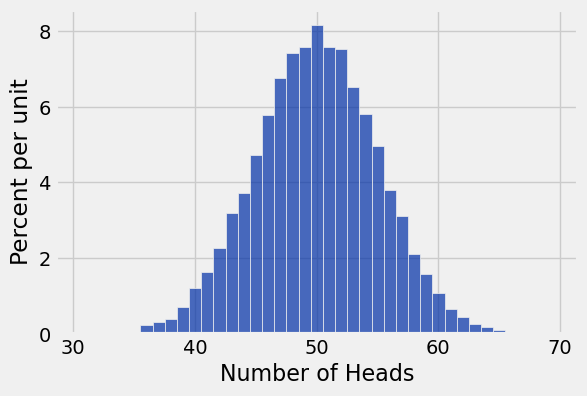

In [36]:
simulation_results.hist('Number of Heads', bins = np.arange(30.5, 69.6, 1))

--- 

# Chance

---

## Overview

* [The Monty Hall Problem](#The-Monty-Hall-Problem)
* [Probability](#Probability)
* [Problem-Solving Method](#Problem-Solving-Method)

---

## The Monty Hall Problem

---

### Summary of the Problem

* There are 3 closed doors.
* One door has a prize and two doors have what is considered not to be a prize.
* The contestant selects a door.
* The host reveals what is behind the remaining door that has not been selected without the prize.
* The contestant has the chance to change doors.
* Are the contestant's chance of winning improved by switching doors?

<a href="https://en.wikipedia.org/wiki/Monty_Hall_problem" title="Wikipedia - Monty Hall Problem"><img src="./Monty_open_door.png" width = 40%><a/>

---

### Monty Hall

Create a simulation of the Monty Hall game.

* You can optionally learn more about the case analysis for this problem consider reviewing [part 1](https://youtu.be/e7c6_h0Zf6U) and [part 2](https://youtu.be/e3cCUAGHIOI) from the OLI Probability and Statistics course materials.
* To provide you with more insight about simulating the game play, engage with [a simulation produced produced by rossmanchance.com](https://www.rossmanchance.com/applets/2021/montyhall/Monty.html).

In [37]:
goats = make_array('first goat', 'second goat')

In [38]:
def other_goat(a_goat):
    '''other_goat accepts either the string 'first goat' or the string 'second goat' and returns the other goat as a string.'''
    if a_goat == 'first goat':
        return 'second goat'
    elif a_goat == 'second goat':
        return 'first goat'
    else:
        print("a_goat should name 'first goat' or 'second goat'.")

In [39]:
other_goat('first goat'), other_goat('second goat'), other_goat('watermelon')

a_goat should name 'first goat' or 'second goat'.


('second goat', 'first goat', None)

In [40]:
hidden_behind_doors = np.append(goats, 'car')
hidden_behind_doors

array(['first goat', 'second goat', 'car'],
      dtype='<U11')

In [41]:
def monty_hall():
    '''
    monty_hall runs a simulation of the monty hall problem 
    where the three doors are represented as the strings 'first goat',
    'second goat', and 'car'. This function returns a list with random 
    choice from the contestant, the goat revealed by the host, and the remaining car/goat.
    '''
    doors = make_array('car', 'first goat', 'second goat')
    goats = make_array('first goat', 'second goat')
    contestant_choice = np.random.choice(doors)
    
    if contestant_choice == 'first goat':
        monty_choice = 'second goat'
        remaining_door = 'car'
        
    elif contestant_choice == 'second goat':
        monty_choice = 'first goat'
        remaining_door = 'car'
        
    elif contestant_choice == 'car':
        monty_choice = np.random.choice(goats)
        remaining_door = other_goat(monty_choice)
        
    return [contestant_choice, monty_choice, remaining_door]

In [43]:
monty_hall()

['car', 'second goat', 'first goat']

---

Store the results of several random simulations of the Monty Hall game in a Table.

In [44]:
games = Table(['Guess', 'Revealed', 'Remaining'])

In [45]:
games

Guess,Revealed,Remaining


In [46]:
games = Table(['Guess', 'Revealed', 'Remaining'])

for _ in np.arange(3000):
    games = games.with_row(monty_hall())
    
games

Guess,Revealed,Remaining
car,second goat,first goat
second goat,first goat,car
first goat,second goat,car
car,first goat,second goat
second goat,first goat,car
second goat,first goat,car
first goat,second goat,car
car,first goat,second goat
second goat,first goat,car
second goat,first goat,car


---

Determine the proportion of times that the player would have won if they switched doors.

In [47]:
def switch_to_win(remaining):
    if remaining == 'car':
        return True
    else:
        return False

In [48]:
games = games.with_column(
    'Switch to Win', 
    games.apply(switch_to_win, 'Remaining')
)
games

Guess,Revealed,Remaining,Switch to Win
car,second goat,first goat,False
second goat,first goat,car,True
first goat,second goat,car,True
car,first goat,second goat,False
second goat,first goat,car,True
second goat,first goat,car,True
first goat,second goat,car,True
car,first goat,second goat,False
second goat,first goat,car,True
second goat,first goat,car,True


In [49]:
switch_to_win_prob = switch_to_win(games)
switch_to_win_prob

False

In [50]:
original_choice = games.group('Guess')
original_choice

Guess,count
car,1025
first goat,1015
second goat,960


In [51]:
remaining_door = games.group('Remaining')
remaining_door

Remaining,count
car,1975
first goat,506
second goat,519


In [52]:
joined = original_choice.join('Guess', remaining_door, 'Remaining')
combined = joined.relabeled(0, 'Item').relabeled(1, 'Original Door').relabeled(2, 'Remaining Door')
combined

Item,Original Door,Remaining Door
car,1025,1975
first goat,1015,506
second goat,960,519


---

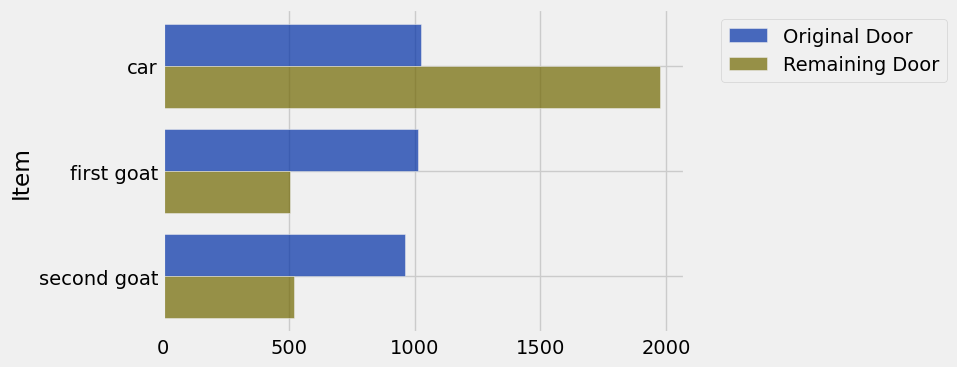

In [53]:
combined.barh(0)

## Probability

---

### Basics

* Lowest value: 0 (or 0%) --- Chance of event that is impossible.
* Highest value: 1 (or 100%) --- Chance of event that is certain.
* Complement: If an event has chance 70%, then the chance that it doesn’t happen is:
    * 100% - 70% = 30%
    * 1 - 0.7 = 0.3


---

### Equally Likely Outcomes

Assuming all outcomes are equally likely, the probability of an event $A$ is:
                
$$P(A) = \frac{\text{number of outcomes that make $A$ happen}}{\text{total number of outcomes}}$$
                             
The terms chance and probability are often interchangeable.

---

In [54]:
rolls = np.arange(1, 51, 1)
results = Table().with_columns(
    'Rolls', rolls,
    'Chance of at least one 6', 1 - (5/6)**rolls
)
results

Rolls,Chance of at least one 6
1,0.166667
2,0.305556
3,0.421296
4,0.517747
5,0.598122
6,0.665102
7,0.720918
8,0.767432
9,0.806193
10,0.838494


The chance that a 6 appears at least once rises rapidly as the number of rolls increases.

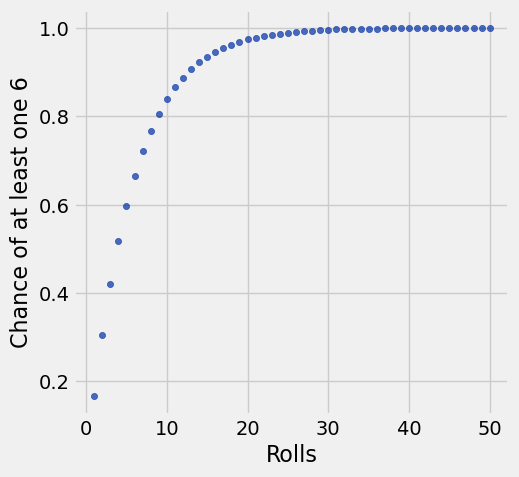

In [55]:
results.scatter('Rolls')

In [56]:
results.where('Rolls', are.equal_to(50))

Rolls,Chance of at least one 6
50,0.99989


---

### An Interpretation

One way to interpret the approximately 16.67% chance of selecting a Queen followed by a King is through a [frequentist perspective](https://en.wikipedia.org/wiki/Frequentist_probability): if the situation were repeated many times, the proportion of Queen-King outcomes would get closer and closer to 0.1667.

1. **Run** the following code cell.  
2. **Click** *Generate New Data* to simulate the scenario.  
3. **Adjust** the *Reveal Proportion* slider to see how the proportion of Queen-King outcomes changes as repetitions increase.  
4. **Regenerate** new data and continue to explore the trend in the proportion.

In [57]:
cards = ['A', 'K', 'Q']
steps = 25

simulation_data = None

def run_simulation(max_reps):
    reps_array = np.arange(1, max_reps + 1, steps)
    successes = np.zeros_like(reps_array, dtype=float)
    
    for i, reps in enumerate(reps_array):
        count = 0
        for _ in range(reps-1):
            first, second = np.random.choice(cards, 2, replace=False)
            if first=='Q' and second=='K':
                count += 1
        successes[i] = count / reps
    return reps_array, successes

def plot_simulation(change=None):
    if simulation_data is None:
        return
    
    reps_array, successes = simulation_data
    cutoff = max(1, int(len(reps_array) * reveal_slider.value))
    
    out_plot.clear_output(wait=True)
    with out_plot:
        plt.figure(figsize=(10,5))
        plt.plot(reps_array[:cutoff], successes[:cutoff], label='Simulated Proportion')
        plt.plot([0, reps_array[-1]], [1/6, 1/6], 'r--', linewidth=2, label='Expected 1/6')
        plt.xlabel('Repetitions')
        plt.ylabel('Queen-King Proportion')
        plt.ylim(0, 0.5)
        plt.title('Simulation of Queen-King Proportion')
        plt.legend()
        plt.show()

def generate_new_data(b):
    global simulation_data
    simulation_data = run_simulation(max_reps_slider.value)
    reveal_slider.value = 0.0
    plot_simulation()

max_reps_slider = widgets.IntSlider(
    value=2500, min=100, max=5000, step=100, 
    description="Max Reps:",
    style={'description_width': '120px'}, 
    layout=widgets.Layout(width='300px')
)

reveal_slider = widgets.FloatSlider(
    value=0.0, min=0.0, max=1.0, step=0.01, 
    description="Reveal Proportion:",
    style={'description_width': '120px'},  
    layout=widgets.Layout(width='300px')
)

generate_button = widgets.Button(description="Generate New Data")
generate_button.on_click(generate_new_data)
reveal_slider.observe(plot_simulation, names='value')
out_plot = widgets.Output()
ui = widgets.VBox([max_reps_slider, reveal_slider, generate_button])
display(ui, out_plot)

Output()

---

### Multiplication Rule

* Chance that two events $A$ and $B$ both happen is $P(\text{$A$ happens}) \times P(\text{$B$ happens given that $A$ has happened})$
* The answer is less than or equal to each of the two chances being multiplied
* The more conditions you have to satisfy, the less likely you are to satisfy them all


---

# Sampling

---

## Outline

* [Sampling](#Sampling)
* [Sampling with Technology](#Sampling-with-Technology)

---

## Sampling

---

### Random Samples

<a href="https://en.wikipedia.org/wiki/Sampling_(statistics)"><img src="./simple_random_sampling.png" width=400px alt="A visual representation of selecting a simple random sample."/></a>

* Population: Set of all elements from whom a sample will be drawn
* Deterministic sample: The sampling scheme doesn't involve chance
* Random (Probability) sample: 
    * Before the sample is drawn, you have to know the selection probability of every group of people in the population
    * Not all individuals/groups have to have an equal chance of being selected
    * If the chances are equal, then the sample is a simple random sample.

---

### Sample of Convenience

* Example: sample consists of whoever walks by
* Just because you think you're sampling "randomly", doesn't mean you have a random sample.
* If you can't figure out the following ahead of time, then you don't have a random sample
    * what's the population
    * what's the chance of selection, for each group in the population

---

### With and Without Replacement

<a href="https://towardsdatascience.com/an-introduction-to-probability-sampling-methods-7a936e486b5/"><img src="./sampling.webp" width=700px alt="A visual representation of sampling with and without replacement."/></a>

* Sampling with Replacement:
    * One event happening does not impact the chance of another event happening
    * Associated with the concept called independent events.
* Sampling without Replacement:
    * One event happening may impact the chance of another event happening
    * Associated with the concept called dependent events.

---

## Sampling with Technology

---

### Sampling from Arrays and Tables

* Sampling from a table
    * Use can use `take` to systematically sample data from a table 
    * `tbl.sample(k=n, with_replacement=True)`:
        * Randomly samples with replacement `n` rows from `tbl` and creates a new table
        * `k` is `tbl.num_rows` by default
        * `with_replacement` is `True` by default
* Sampling from an array
    * `np.random.choice(a=an_array, size=n, replace=True)`:
        * Randomly samples with replacement `n` elements from the elements in `an_array`
        * `size` is 1 by default
        * `replace` is `True` by default

---

### Demo: Sampling from Arrays and Tables

In [58]:
united = Table.read_table('united_summer2015.csv')
united

Date,Flight Number,Destination,Delay
6/1/15,73,HNL,257
6/1/15,217,EWR,28
6/1/15,237,STL,-3
6/1/15,250,SAN,0
6/1/15,267,PHL,64
6/1/15,273,SEA,-6
6/1/15,278,SEA,-8
6/1/15,292,EWR,12
6/1/15,300,HNL,20
6/1/15,317,IND,-10


---

Demonstrate how to use the `take` method to sample the data in a few ways.

In [59]:
united.column('Delay').min()

-16

In [60]:
united.column('Delay').max()

580

---

In [61]:
united.column('Delay').min()


-16

In [62]:
united.column('Delay').max()

580

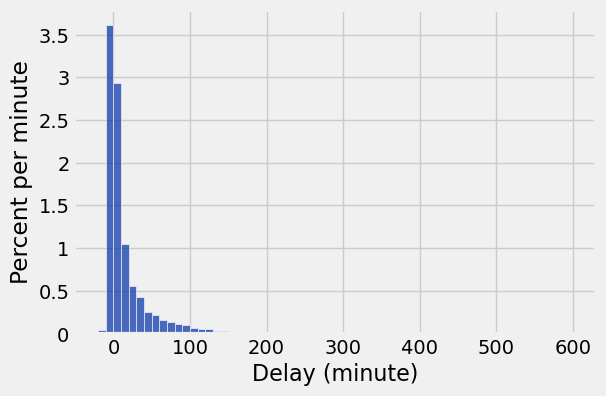

In [63]:
delay_bins = np.append(np.arange(-20, 301, 10), 600)
united.hist('Delay', bins = delay_bins, unit = 'minute')

In [64]:
united.where('Delay', are.above(200)).num_rows/united.num_rows

0.008390596745027125

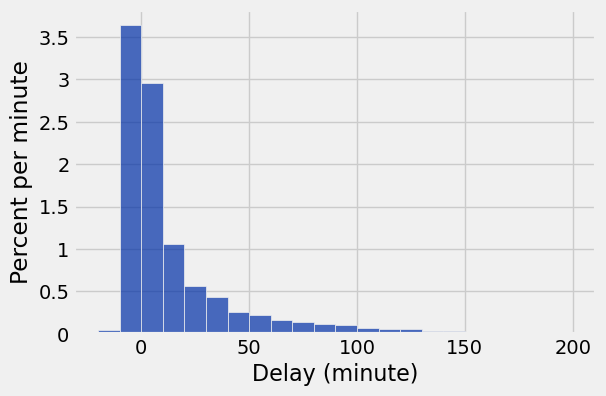

In [65]:
delay_bins = np.arange(-20, 201, 10)
united.hist('Delay', bins = delay_bins, unit = 'minute')

In [66]:
united.where('Delay', are.between(0, 10)).num_rows/united.num_rows

0.2935985533453888

In [68]:
def empirical_hist_delay(n):
    united.sample(n).hist('Delay', bins = delay_bins, unit = 'minute')

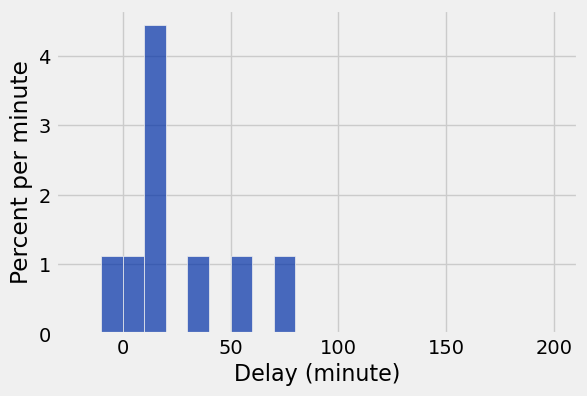

In [69]:
empirical_hist_delay(10)

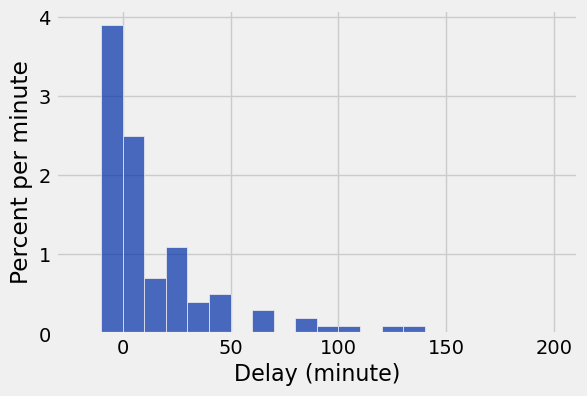

In [70]:
empirical_hist_delay(100)

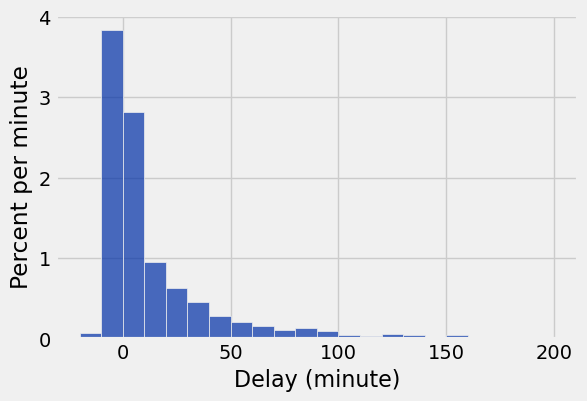

In [71]:
empirical_hist_delay(1000)

--- 

## Attribution

This content is licensed under the <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License (CC BY-NC-SA 4.0)</a> and derived from the <a href="https://www.data8.org/">Data 8: The Foundations of Data Science</a> offered by the University of California, Berkeley.

<img src="./by-nc-sa.png" width=100px>